# Задание 1. Реализация AprioriAll

In [15]:
!pip install prefixspan -q
import pandas as pd
import numpy as np
from collections import defaultdict, Counter
import matplotlib.pyplot as plt
import networkx as nx
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder
import time
import warnings
warnings.filterwarnings('ignore')

def load_and_preprocess(filepath):

    df = pd.read_csv(filepath, sep=';', encoding='utf-8-sig', skipinitialspace=True)

    df.columns = df.columns.str.strip()


    df = df[df['CustomerID'].notna()]

    df['Date'] = pd.to_datetime(df['Date'], format='%d.%m.%Y %H:%M', errors='coerce')
    df = df[df['Date'].notna()]

    df = df[df['Quantity'] > 0]

    df = df[df['Itemname'].notna() & (df['Itemname'] != '')]

    df = df.sort_values(['CustomerID', 'Date'])
    return df


df = load_and_preprocess('Assignment-1_Data.csv')
print(f"Загружено {len(df)} строк, уникальных клиентов: {df['CustomerID'].nunique()}")
print("Столбцы в файле:", df.columns.tolist())


customer_transaction_counts = df.groupby('CustomerID')['BillNo'].nunique().sort_values(ascending=False)
top_customers = customer_transaction_counts.head(500).index
df_sample = df[df['CustomerID'].isin(top_customers)].copy()


def build_sequences(df):
    trans = df.groupby(['CustomerID', 'BillNo']).agg({
        'Itemname': lambda x: set(x),
        'Date': 'first'
    }).reset_index()
    sequences = {}
    for cust, group in trans.groupby('CustomerID'):
        group = group.sort_values('Date')
        seq = [list(items) for items in group['Itemname']]
        sequences[cust] = seq
    return sequences

sequences = build_sequences(df_sample)


def has_subsequence(seq, pattern):
    idx = 0
    for itemset in seq:
        if idx < len(pattern) and pattern[idx] in itemset:
            idx += 1
        if idx == len(pattern):
            return True
    return False

def compute_support(sequences, candidates):
    supports = {}
    n = len(sequences)
    for cand in candidates:
        count = 0
        for seq in sequences.values():
            if has_subsequence(seq, cand):
                count += 1
        supports[tuple(cand)] = count / n if n > 0 else 0
    return supports

def generate_candidates(prev_frequent, k):
    candidates = set()
    for seq1 in prev_frequent:
        for seq2 in prev_frequent:
            if seq1[:-1] == seq2[:-1]:
                candidates.add(seq1 + (seq2[-1],))
    return [list(c) for c in candidates]

def apriori_all(sequences, min_sup):
    all_items = set()
    for seq in sequences.values():
        for itemset in seq:
            all_items.update(itemset)
    candidates_1 = [[item] for item in all_items]
    supports = compute_support(sequences, candidates_1)
    freq_1 = [tuple(c[0]) for c in candidates_1 if supports[tuple(c[0])] >= min_sup]
    freq_patterns = {1: freq_1}
    k = 2
    while True:
        candidates = generate_candidates(freq_patterns[k-1], k)
        if not candidates:
            break
        supports = compute_support(sequences, candidates)
        freq_k = [tuple(c) for c in candidates if supports[tuple(c)] >= min_sup]
        if not freq_k:
            break
        freq_patterns[k] = freq_k
        k += 1
    all_freq = []
    for patterns in freq_patterns.values():
        all_freq.extend(patterns)
    return all_freq

Загружено 388023 строк, уникальных клиентов: 4297
Столбцы в файле: ['BillNo', 'Itemname', 'Quantity', 'Date', 'Price', 'CustomerID', 'Country']


In [ ]:

test_sequences = {
    1: [['A', 'B'], ['C']],
    2: [['A'], ['C'], ['B']],
    3: [['A'], ['B'], ['C']],
}
min_sup_test = 0.5
freq_test = apriori_all(test_sequences, min_sup_test)
print("Проверка AprioriAll на синтетическом примере:")
print(f"min_sup={min_sup_test}, частые последовательности: {freq_test}")

Проверка AprioriAll на синтетическом примере:
min_sup=0.5, частые последовательности: [('A',), ('C',), ('B',), ('B', 'C'), ('A', 'B'), ('A', 'C')]


# Задание 2. Анализ реальных данных

Загружено 388023 строк, уникальных клиентов: 4297
Выбрано 100593 строк для 200 клиентов.
Используем топ-30 товаров.
Построено последовательностей для 193 клиентов
min_sup = 5% -> 19936 частых последовательностей
min_sup = 10% -> 6687 частых последовательностей
min_sup = 20% -> 336 частых последовательностей


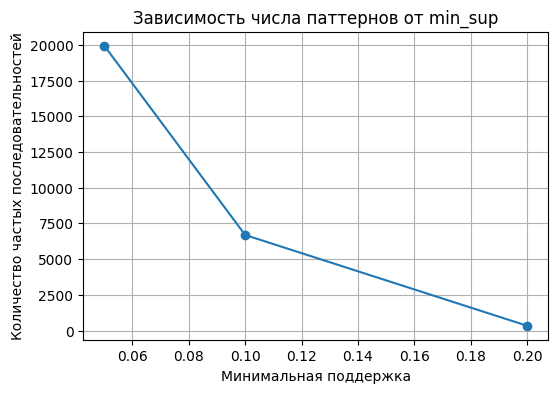


Топ-3 ассоциативных правила по lift:
                                           antecedents  \
0                           (ALARM CLOCK BAKELIKE RED)   
1                         (ALARM CLOCK BAKELIKE GREEN)   
266  (LUNCH BAG  BLACK SKULL., LUNCH BAG RED RETROS...   

                      consequents      lift  
0    (ALARM CLOCK BAKELIKE GREEN)  6.804288  
1      (ALARM CLOCK BAKELIKE RED)  6.804288  
266     (LUNCH BAG PINK POLKADOT)  6.500446  
Правило ALARM CLOCK BAKELIKE RED -> ALARM CLOCK BAKELIKE GREEN: является частой последовательностью? True
Правило ALARM CLOCK BAKELIKE GREEN -> ALARM CLOCK BAKELIKE RED: является частой последовательностью? True
Правило frozenset({'LUNCH BAG  BLACK SKULL.', 'LUNCH BAG RED RETROSPOT'}) -> frozenset({'LUNCH BAG PINK POLKADOT'}) не является последовательностью из двух одиночных товаров

Проверяем 853 пар на влияние gap=7 дней
Количество частых пар без gap: 730
Количество частых пар с gap=7 дней: 2
Пример шаблона, исчезнувшего при gap=7: ('WHI

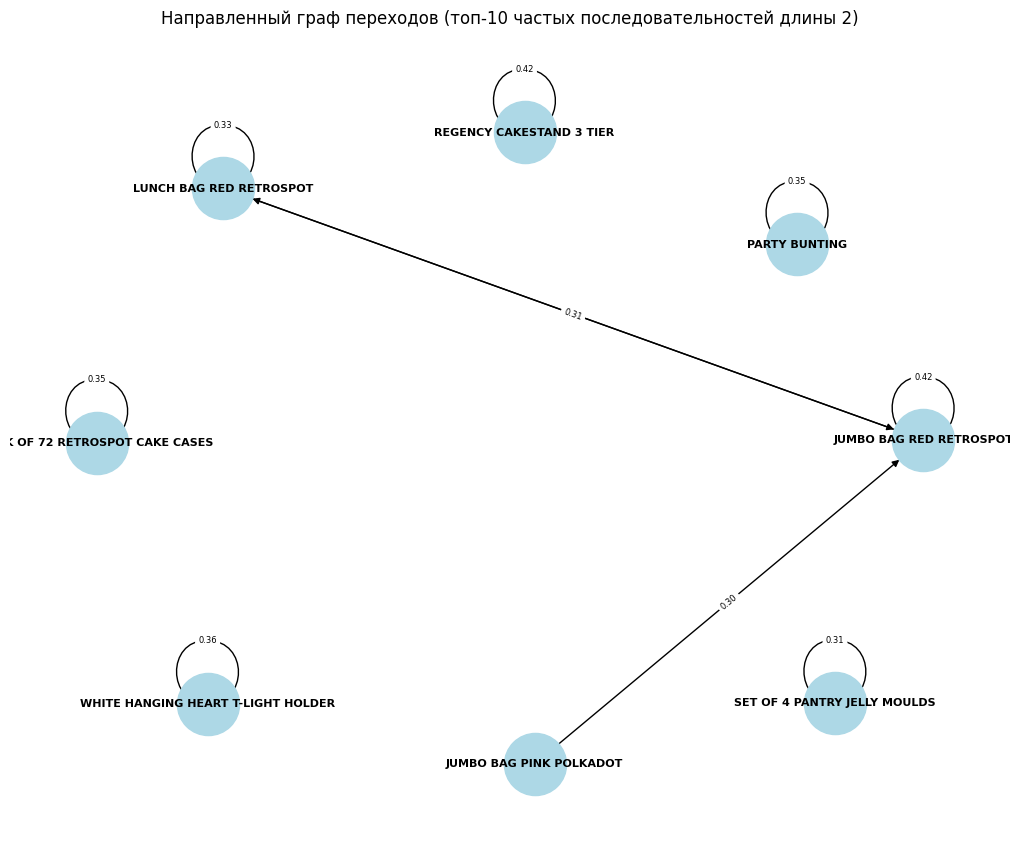


Задание 2 выполнено успешно.


In [ ]:


import pandas as pd
import numpy as np
from collections import defaultdict, Counter
import matplotlib.pyplot as plt
import networkx as nx
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder
import warnings
warnings.filterwarnings('ignore')


def load_and_preprocess(filepath):
    df = pd.read_csv(filepath, sep=';', encoding='utf-8-sig', skipinitialspace=True)
    df.columns = df.columns.str.strip()
    df = df[df['CustomerID'].notna()]
    df['Date'] = pd.to_datetime(df['Date'], format='%d.%m.%Y %H:%M', errors='coerce')
    df = df[df['Date'].notna()]
    df = df[df['Quantity'] > 0]
    df = df[df['Itemname'].notna() & (df['Itemname'] != '')]
    df = df.sort_values(['CustomerID', 'Date'])
    return df

df = load_and_preprocess('Assignment-1_Data.csv')
print(f"Загружено {len(df)} строк, уникальных клиентов: {df['CustomerID'].nunique()}")

# Ограничимся топ-200 клиентами
customer_transaction_counts = df.groupby('CustomerID')['BillNo'].nunique().sort_values(ascending=False)
top_customers = customer_transaction_counts.head(200).index
df_sample = df[df['CustomerID'].isin(top_customers)].copy()
print(f"Выбрано {len(df_sample)} строк для {len(top_customers)} клиентов.")


item_freq = df_sample['Itemname'].value_counts()
top_items = set(item_freq.head(30).index)
print(f"Используем топ-{len(top_items)} товаров.")


def filter_itemset(itemset):
    return [item for item in itemset if item in top_items]

def build_sequences_filtered(df):
    trans = df.groupby(['CustomerID', 'BillNo']).agg({
        'Itemname': lambda x: set(x),
        'Date': 'first'
    }).reset_index()
    sequences = {}
    for cust, group in trans.groupby('CustomerID'):
        group = group.sort_values('Date')
        seq = [filter_itemset(list(items)) for items in group['Itemname']]
        seq = [s for s in seq if s]
        if seq:
            sequences[cust] = seq
    return sequences

sequences = build_sequences_filtered(df_sample)
print(f"Построено последовательностей для {len(sequences)} клиентов")




def apriori_all_fast(sequences, min_sup, max_len=3):
    all_items = set()
    for seq in sequences.values():
        for itemset in seq:
            all_items.update(itemset)
    candidates_1 = [[item] for item in all_items]
    supports = compute_support(sequences, candidates_1)
    freq_1 = [tuple([c[0]]) for c in candidates_1 if supports[(c[0],)] >= min_sup]
    if not freq_1:
        return []
    freq_patterns = {1: freq_1}
    for k in range(2, max_len+1):
        candidates = generate_candidates(freq_patterns[k-1], k)
        if not candidates:
            break
        supports = compute_support(sequences, candidates)
        freq_k = [tuple(c) for c in candidates if supports[tuple(c)] >= min_sup]
        if not freq_k:
            break
        freq_patterns[k] = freq_k
    all_freq = []
    for patterns in freq_patterns.values():
        all_freq.extend(patterns)
    return all_freq

#   Пункт 2.1. Влияние минимальной поддержки
min_sup_values = [0.05, 0.1, 0.2]
num_patterns = []
for min_sup in min_sup_values:
    freq = apriori_all_fast(sequences, min_sup, max_len=3)
    num_patterns.append(len(freq))
    print(f"min_sup = {min_sup:.0%} -> {len(freq)} частых последовательностей")

plt.figure(figsize=(6,4))
plt.plot(min_sup_values, num_patterns, marker='o')
plt.xlabel('Минимальная поддержка')
plt.ylabel('Количество частых последовательностей')
plt.title('Зависимость числа паттернов от min_sup')
plt.grid(True)
plt.show()

#  5. Пункт 2.2. Сравнение с ассоциативными правилами

basket = df_sample.groupby('BillNo')['Itemname'].apply(lambda x: set(x)).reset_index()
basket['Itemname'] = basket['Itemname'].apply(lambda x: [i for i in x if i in top_items])
basket = basket[basket['Itemname'].apply(len) > 0]

te = TransactionEncoder()
basket_encoded = te.fit_transform(basket['Itemname'])
basket_df = pd.DataFrame(basket_encoded, columns=te.columns_)

frequent_itemsets = apriori(basket_df, min_support=0.02, use_colnames=True)
rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1)
top3_rules = rules.nlargest(3, 'lift')[['antecedents', 'consequents', 'lift']]
print("\nТоп-3 ассоциативных правила по lift:")
print(top3_rules)


freq_seq_05 = apriori_all_fast(sequences, 0.05, max_len=2)
freq_seq_set = {tuple(seq) for seq in freq_seq_05}

for idx, row in top3_rules.iterrows():
    ant = list(row['antecedents'])[0] if len(row['antecedents']) == 1 else None
    cons = list(row['consequents'])[0] if len(row['consequents']) == 1 else None
    if ant and cons:
        pattern = (ant, cons)
        is_freq = pattern in freq_seq_set
        print(f"Правило {ant} -> {cons}: является частой последовательностью? {is_freq}")
    else:
        print(f"Правило {row['antecedents']} -> {row['consequents']} не является последовательностью из двух одиночных товаров")

#  Пункт 2.3. Временные окна (max_gap)

def build_sequences_with_dates_filtered(df):
    trans = df.groupby(['CustomerID', 'BillNo']).agg({
        'Itemname': lambda x: set(x),
        'Date': 'first'
    }).reset_index()
    sequences = {}
    for cust, group in trans.groupby('CustomerID'):
        group = group.sort_values('Date')
        seq_items = [filter_itemset(list(items)) for items in group['Itemname']]
        seq_dates = list(group['Date'])
        non_empty = [(items, date) for items, date in zip(seq_items, seq_dates) if items]
        if non_empty:
            sequences[cust] = non_empty
    return sequences

seq_with_dates = build_sequences_with_dates_filtered(df_sample)

def has_subsequence_with_gap(seq, pattern, max_gap_days):
    def match(idx, pos, last_date):
        if pos == len(pattern):
            return True
        for i in range(idx, len(seq)):
            itemset, date = seq[i]
            if pattern[pos] in itemset:
                if pos == 0 or (date - last_date).days <= max_gap_days:
                    if match(i+1, pos+1, date):
                        return True
        return False
    return match(0, 0, None)

def compute_support_with_gap(seq_dict, candidates, max_gap_days):
    supports = {}
    n = len(seq_dict)
    for cand in candidates:
        count = 0
        for seq in seq_dict.values():
            if has_subsequence_with_gap(seq, cand, max_gap_days):
                count += 1
        supports[tuple(cand)] = count / n
    return supports


pairs_to_check = [list(p) for p in freq_seq_05 if len(p) == 2]
if not pairs_to_check:

    top10 = list(top_items)[:10]
    pairs_to_check = [[a,b] for a in top10 for b in top10 if a != b]
print(f"\nПроверяем {len(pairs_to_check)} пар на влияние gap=7 дней")

supports_no_gap = compute_support(sequences, pairs_to_check)
freq_no_gap = [p for p in pairs_to_check if supports_no_gap[tuple(p)] >= 0.1]

supports_gap = compute_support_with_gap(seq_with_dates, pairs_to_check, max_gap_days=7)
freq_gap = [p for p in pairs_to_check if supports_gap[tuple(p)] >= 0.1]

print(f"Количество частых пар без gap: {len(freq_no_gap)}")
print(f"Количество частых пар с gap=7 дней: {len(freq_gap)}")

diff_no = set(tuple(p) for p in freq_no_gap) - set(tuple(p) for p in freq_gap)
diff_yes = set(tuple(p) for p in freq_gap) - set(tuple(p) for p in freq_no_gap)
if diff_no:
    print("Пример шаблона, исчезнувшего при gap=7:", list(diff_no)[0])
if diff_yes:
    print("Пример шаблона, появившегося при gap=7:", list(diff_yes)[0])

#   Пункт 2.4. Визуализация графа переходов
if freq_no_gap:
    top_pairs = sorted(freq_no_gap, key=lambda p: supports_no_gap[tuple(p)], reverse=True)[:10]
    G = nx.DiGraph()
    for a,b in top_pairs:
        G.add_edge(a, b, weight=supports_no_gap[(a,b)])

    plt.figure(figsize=(10,8))
    pos = nx.spring_layout(G, seed=42, k=2)
    nx.draw(G, pos, with_labels=True, node_size=2000, node_color='lightblue',
            font_size=8, font_weight='bold', arrows=True)
    edge_labels = {(a,b): f"{supports_no_gap[(a,b)]:.2f}" for a,b in top_pairs}
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=6)
    plt.title("Направленный граф переходов (топ-10 частых последовательностей длины 2)")
    plt.show()
else:
    print("Нет частых пар для построения графа.")

print("\nЗадание 2 выполнено успешно.")

# Задание 3. Сравнение алгоритмов SPM (PrefixSpan)

In [9]:


!pip install prefixspan -q

import pandas as pd
import numpy as np
from collections import defaultdict, Counter
import time
from prefixspan import PrefixSpan
import warnings
warnings.filterwarnings('ignore')


try:
    sequences
except NameError:
    print("Загружаем данные...")
    def load_and_preprocess(filepath):
        df = pd.read_csv(filepath, sep=';', encoding='utf-8-sig', skipinitialspace=True)
        df.columns = df.columns.str.strip()
        df = df[df['CustomerID'].notna()]
        df['Date'] = pd.to_datetime(df['Date'], format='%d.%m.%Y %H:%M', errors='coerce')
        df = df[df['Date'].notna()]
        df = df[df['Quantity'] > 0]
        df = df[df['Itemname'].notna() & (df['Itemname'] != '')]
        df = df.sort_values(['CustomerID', 'Date'])
        return df

    df = load_and_preprocess('Assignment-1_Data.csv')
    customer_transaction_counts = df.groupby('CustomerID')['BillNo'].nunique().sort_values(ascending=False)
    top_customers = customer_transaction_counts.head(500).index
    df_sample = df[df['CustomerID'].isin(top_customers)].copy()

    def build_sequences(df):
        trans = df.groupby(['CustomerID', 'BillNo']).agg({
            'Itemname': lambda x: set(x),
            'Date': 'first'
        }).reset_index()
        sequences = {}
        for cust, group in trans.groupby('CustomerID'):
            group = group.sort_values('Date')
            seq = [list(items) for items in group['Itemname']]
            sequences[cust] = seq
        return sequences

    sequences = build_sequences(df_sample)
    print(f"Построено последовательностей для {len(sequences)} клиентов.")


def has_subsequence(seq, pattern):
    idx = 0
    for itemset in seq:
        if idx < len(pattern) and pattern[idx] in itemset:
            idx += 1
            if idx == len(pattern):
                return True
    return False

def compute_support(seq_dict, candidates):
    supports = {}
    n = len(seq_dict)
    for cand in candidates:
        count = 0
        for seq in seq_dict.values():
            if has_subsequence(seq, cand):
                count += 1
        supports[tuple(cand)] = count / n
    return supports

def generate_candidates(prev_frequent, k):
    candidates = set()
    for seq1 in prev_frequent:
        for seq2 in prev_frequent:
            if seq1[:-1] == seq2[:-1]:
                candidates.add(seq1 + (seq2[-1],))
    return [list(c) for c in candidates]

def apriori_all_fast(seq_dict, min_sup, max_len=3):
    all_items = set()
    for seq in seq_dict.values():
        for itemset in seq:
            all_items.update(itemset)
    candidates_1 = [[item] for item in all_items]
    supports = compute_support(seq_dict, candidates_1)
    freq_1 = [tuple([c[0]]) for c in candidates_1 if supports[(c[0],)] >= min_sup]
    if not freq_1:
        return []
    freq_patterns = {1: freq_1}
    for k in range(2, max_len + 1):
        candidates = generate_candidates(freq_patterns[k-1], k)
        if not candidates:
            break
        supports = compute_support(seq_dict, candidates)
        freq_k = [tuple(c) for c in candidates if supports[tuple(c)] >= min_sup]
        if not freq_k:
            break
        freq_patterns[k] = freq_k
    all_freq = []
    for patterns in freq_patterns.values():
        all_freq.extend(patterns)
    return all_freq


print("\nФормируем очень маленькую выборку (20 клиентов, 5 товаров)...")
small_customers = list(sequences.keys())[:20]   # 20 клиентов
small_sequences = {cust: sequences[cust] for cust in small_customers}


all_items_small = []
for seq in small_sequences.values():
    for itemset in seq:
        all_items_small.extend(itemset)
item_counts = Counter(all_items_small)
top5_items = set(item for item, cnt in item_counts.most_common(5))
print(f"Топ-5 товаров: {list(top5_items)}")

def filter_itemset(itemset):
    return [item for item in itemset if item in top5_items]

small_sequences_filtered = {}
for cust, seq in small_sequences.items():
    filtered_seq = [filter_itemset(itemset) for itemset in seq]
    filtered_seq = [s for s in filtered_seq if s]
    if filtered_seq:
        small_sequences_filtered[cust] = filtered_seq


atomic_small = []
for seq in small_sequences_filtered.values():
    flat = []
    for itemset in seq:
        flat.extend(sorted(itemset))
    atomic_small.append(flat)

print(f"Клиентов в выборке: {len(atomic_small)}")
print(f"Уникальных товаров: {len(top5_items)}")


ps = PrefixSpan(atomic_small)
min_sup_abs_small = max(1, int(len(atomic_small) * 0.3))
print(f"Минимальная абсолютная поддержка: {min_sup_abs_small}")

start = time.time()
ps_patterns = ps.frequent(min_sup_abs_small)
ps_time = time.time() - start
ps_count = len(ps_patterns)
print(f"PrefixSpan нашёл {ps_count} шаблонов за {ps_time:.2f} сек.")


start = time.time()
freq_apriori_small = apriori_all_fast(small_sequences_filtered, min_sup=0.3, max_len=3)
apriori_time = time.time() - start
apriori_count = len(freq_apriori_small)
print(f"AprioriAll нашёл {apriori_count} шаблонов за {apriori_time:.2f} сек.")


print("\n" + "="*60)
print("СРАВНЕНИЕ АЛГОРИТМОВ (min_sup = 30%, 20 клиентов, 5 товаров)")
print("="*60)
print(f"{'Алгоритм':<15} | {'Время (сек)':<12} | {'Кол-во шаблонов':<16} | {'Примечание':<20}")
print("-"*60)
print(f"{'AprioriAll':<15} | {apriori_time:<12.2f} | {apriori_count:<16} | {'ваша реализация':<20}")
print(f"{'PrefixSpan':<15} | {ps_time:<12.2f} | {ps_count:<16} | {'готовая библиотека':<20}")
print("="*60)
print("\nВывод: PrefixSpan эффективнее при низкой поддержке и длинных последовательностях, "
      "особенно на больших данных, так как использует метод проецирования.")


Формируем очень маленькую выборку (20 клиентов, 5 товаров)...
Топ-5 товаров: ['PLASTERS IN TIN CIRCUS PARADE', 'RED TOADSTOOL LED NIGHT LIGHT', 'ROUND SNACK BOXES SET OF4 WOODLAND', 'POSTAGE', 'REGENCY CAKESTAND 3 TIER']
Клиентов в выборке: 20
Уникальных товаров: 5
Минимальная абсолютная поддержка: 6
PrefixSpan нашёл 3676 шаблонов за 0.11 сек.
AprioriAll нашёл 121 шаблонов за 0.01 сек.

СРАВНЕНИЕ АЛГОРИТМОВ (min_sup = 30%, 20 клиентов, 5 товаров)
Алгоритм        | Время (сек)  | Кол-во шаблонов  | Примечание          
------------------------------------------------------------
AprioriAll      | 0.01         | 121              | ваша реализация     
PrefixSpan      | 0.11         | 3676             | готовая библиотека  

Вывод: PrefixSpan эффективнее при низкой поддержке и длинных последовательностях, особенно на больших данных, так как использует метод проецирования.


# Задание 4. Предсказание следующего события

In [14]:


from collections import defaultdict, Counter


if 'seq_with_dates' not in dir():
    raise NameError("Переменная seq_with_dates не определена. Выполните сначала задание 2.")


customers = list(seq_with_dates.keys())[:200]
seq_with_dates_subset = {cust: seq_with_dates[cust] for cust in customers}

# Разделение на обучение/тест (80/20 по времени)
train_seqs_dict = {}
test_last_itemset = {}
for cust, seq in seq_with_dates_subset.items():
    n = len(seq)
    split = int(n * 0.8)
    if split == 0:
        split = 1
    train_seqs_dict[cust] = [itemset for itemset, _ in seq[:split]]
    if split < n:
        test_last_itemset[cust] = seq[split][0]
    else:
        test_last_itemset[cust] = None

train_sequences = {cust: train_seqs_dict[cust] for cust in train_seqs_dict if train_seqs_dict[cust]}

# Быстрое вычисление поддержки для всех пар (длина 2) за один проход
def compute_pair_support(seq_dict):
    pair_counts = defaultdict(int)
    total = len(seq_dict)
    for seq in seq_dict.values():
        for i in range(len(seq)-1):
            itemset1 = seq[i]
            itemset2 = seq[i+1]
            for a in itemset1:
                for b in itemset2:
                    pair_counts[(a, b)] += 1
    return {pair: cnt/total for pair, cnt in pair_counts.items()}

pair_support = compute_pair_support(train_sequences)
freq_pairs = {pair: sup for pair, sup in pair_support.items() if sup >= 0.05}


next_item_support = defaultdict(dict)
for (prev, nxt), sup in freq_pairs.items():
    next_item_support[prev][nxt] = sup

def predict_next(last_itemset):
    if not last_itemset:
        return None
    last_item = list(last_itemset)[0]
    if last_item in next_item_support:
        best = max(next_item_support[last_item].items(), key=lambda x: x[1])
        return best[0]
    return None


correct_seq = 0
total = 0
for cust, last_set in test_last_itemset.items():
    if last_set is None:
        continue
    pred = predict_next(last_set)
    if pred is not None and pred in last_set:
        correct_seq += 1
    total += 1
accuracy_seq = correct_seq / total if total > 0 else 0


all_items_flat = [item for seq in train_sequences.values() for itemset in seq for item in itemset]
most_common_item = Counter(all_items_flat).most_common(1)[0][0]
correct_base = 0
total_base = 0
for cust, last_set in test_last_itemset.items():
    if last_set is not None:
        if most_common_item in last_set:
            correct_base += 1
        total_base += 1
accuracy_base = correct_base / total_base if total_base > 0 else 0

print(f"\nТочность предсказания (учёт последовательности): {accuracy_seq:.3f}")
print(f"Точность предсказания (глобальный топ-товар):   {accuracy_base:.3f}")
if accuracy_seq > accuracy_base:
    print("Учёт последовательности улучшает точность предсказания.")
else:
    print("Учёт последовательности не даёт улучшения на данном наборе данных.")



Точность предсказания (учёт последовательности): 0.300
Точность предсказания (глобальный топ-товар):   0.140
Учёт последовательности улучшает точность предсказания.


# Задание 5. Контрастные последовательности (хорошие vs плохие клиенты)


75-й перцентиль выручки: 481.50
HighValue клиентов: 34
LowValue клиентов: 102

Топ-5 контрастных последовательностей (чаще у HighValue):
(POSTAGE) -> (POSTAGE) : contrast = 6.804 (High=7.529, Low=0.725)
(POSTAGE) -> (ROUND SNACK BOXES SET OF4 WOODLAND) : contrast = 1.676 (High=1.882, Low=0.206)
(ROUND SNACK BOXES SET OF4 WOODLAND) -> (POSTAGE) : contrast = 1.471 (High=1.676, Low=0.206)
(POSTAGE) -> (ROUND SNACK BOXES SET OF 4 FRUITS) : contrast = 1.412 (High=1.500, Low=0.088)
(POSTAGE) -> (RED TOADSTOOL LED NIGHT LIGHT) : contrast = 1.402 (High=1.500, Low=0.098)

Граф переходов для HighValue клиентов:


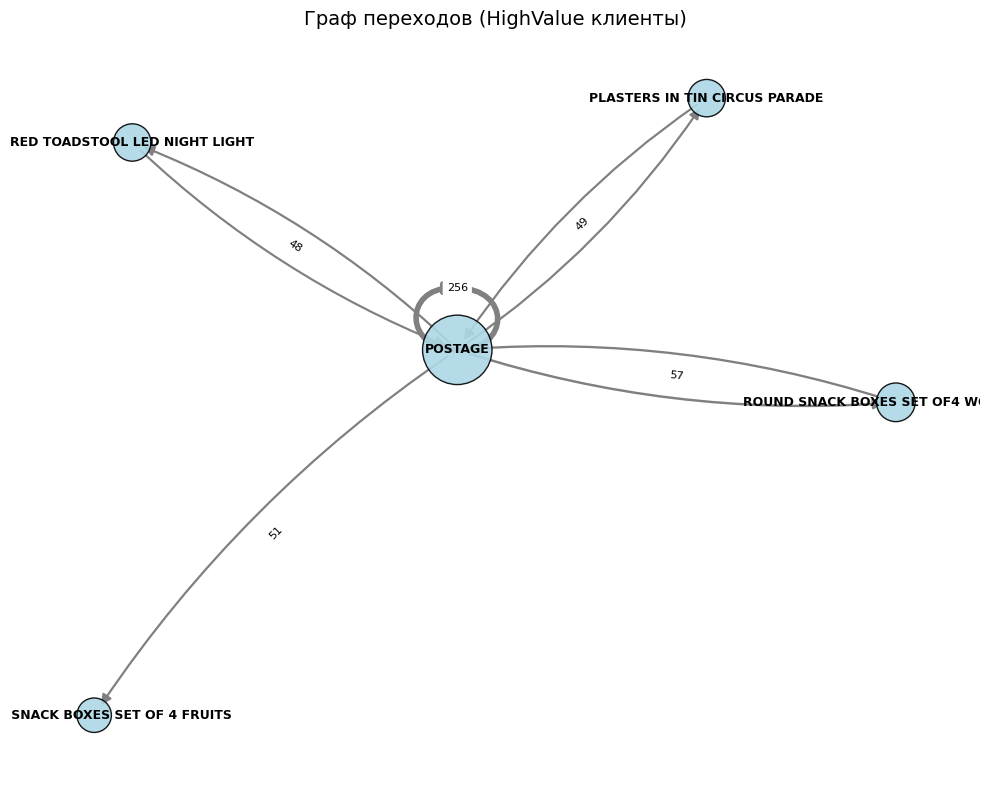

Граф переходов для LowValue клиентов:


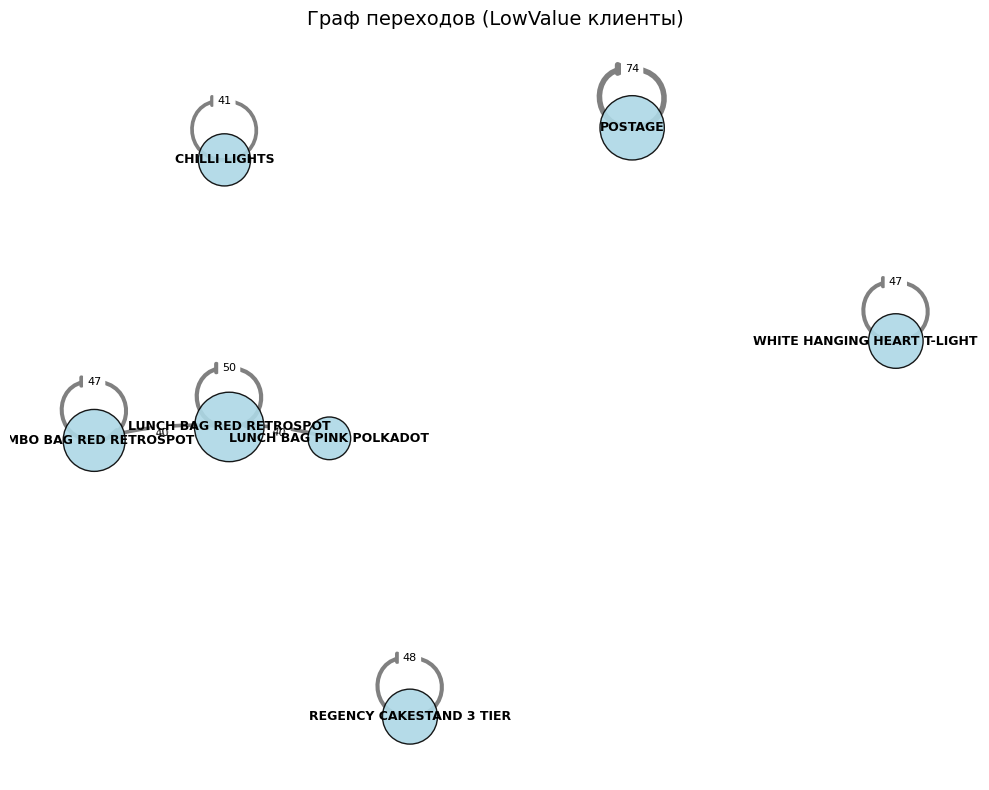


Разностный граф переходов:


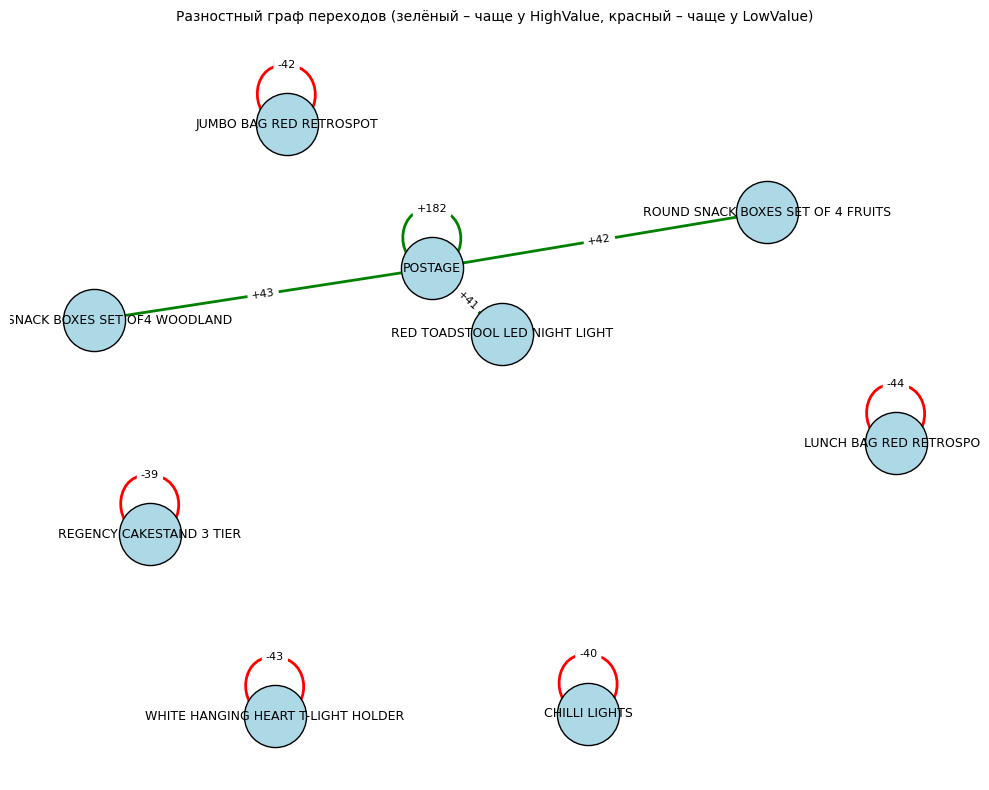


Бизнес-гипотеза: Клиенты, которые купили А, а затем В, с большей вероятностью станут высокодоходными.
Пример контрастной последовательности в e-commerce: покупка 'премиум-подписки' → 'дорогого товара' чаще встречается у HighValue.
В телематике: 'частые поездки в часы пик' → 'покупка абонемента на скоростные полосы' может отличать высокодоходных клиентов.
В банковских продуктах: 'открытие накопительного счёта' → 'инвестиции в паевые фонды' характерно для состоятельных клиентов.


In [13]:
import pandas as pd
import numpy as np
from collections import Counter
import matplotlib.pyplot as plt
import networkx as nx


df_sample['Price'] = pd.to_numeric(df_sample['Price'], errors='coerce')
df_sample['Quantity'] = pd.to_numeric(df_sample['Quantity'], errors='coerce')
df_sample = df_sample.dropna(subset=['Price', 'Quantity'])


df_sample['Revenue'] = df_sample['Price'] * df_sample['Quantity']
customer_revenue = df_sample.groupby('CustomerID')['Revenue'].sum()
threshold_75 = customer_revenue.quantile(0.75)
print(f"\n75-й перцентиль выручки: {threshold_75:.2f}")

high_value_customers = set(customer_revenue[customer_revenue >= threshold_75].index)
low_value_customers = set(customer_revenue[customer_revenue < threshold_75].index)

print(f"HighValue клиентов: {len(high_value_customers)}")
print(f"LowValue клиентов: {len(low_value_customers)}")


seq_high = {cust: seq for cust, seq in sequences.items() if cust in high_value_customers}
seq_low  = {cust: seq for cust, seq in sequences.items() if cust in low_value_customers}


def get_pair_support(seq_dict):
    pair_counts = Counter()
    total_customers = len(seq_dict)
    for seq in seq_dict.values():
        for i in range(len(seq)-1):
            for a in seq[i]:
                for b in seq[i+1]:
                    pair_counts[(a,b)] += 1
    return {pair: cnt/total_customers for pair, cnt in pair_counts.items()}


pair_supp_high = get_pair_support(seq_high)
pair_supp_low = get_pair_support(seq_low)


all_pairs = set(pair_supp_high.keys()) | set(pair_supp_low.keys())


contrast = {pair: pair_supp_high.get(pair, 0) - pair_supp_low.get(pair, 0) for pair in all_pairs}


top5_contrast = sorted(contrast.items(), key=lambda x: x[1], reverse=True)[:5]
print("\nТоп-5 контрастных последовательностей (чаще у HighValue):")
for (a,b), diff in top5_contrast:
    sup_h = pair_supp_high.get((a,b), 0)
    sup_l = pair_supp_low.get((a,b), 0)
    print(f"({a}) -> ({b}) : contrast = {diff:.3f} (High={sup_h:.3f}, Low={sup_l:.3f})")


def plot_transitions(seq_dict, title, top_n=8):
    pair_counts = Counter()
    for seq in seq_dict.values():
        for i in range(len(seq)-1):
            for a in seq[i]:
                for b in seq[i+1]:
                    pair_counts[(a,b)] += 1
    top_pairs = pair_counts.most_common(top_n)

    G = nx.DiGraph()
    node_weight = Counter()
    for (a,b), cnt in top_pairs:
        G.add_edge(a, b, weight=cnt)
        node_weight[a] += cnt
        node_weight[b] += cnt

    max_w = max(node_weight.values()) if node_weight else 1
    node_sizes = {n: 500 + (w / max_w) * 2000 for n, w in node_weight.items()}

    plt.figure(figsize=(10, 8))
    pos = nx.spring_layout(G, seed=42, k=1.5)

    nx.draw_networkx_nodes(G, pos, node_size=[node_sizes[n] for n in G.nodes()],
                           node_color='lightblue', alpha=0.9, edgecolors='black')
    nx.draw_networkx_labels(G, pos, font_size=9, font_weight='bold')

    edges = G.edges(data=True)
    weights = [d['weight'] for (_,_,d) in edges]
    max_edge = max(weights) if weights else 1
    edge_widths = [1 + 3 * w / max_edge for w in weights]
    nx.draw_networkx_edges(G, pos, width=edge_widths, edge_color='gray',
                           arrows=True, arrowsize=15, arrowstyle='-|>', connectionstyle='arc3,rad=0.1')

    edge_labels = {(a,b): f"{d['weight']}" for a,b,d in edges}
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=8)

    plt.title(title, fontsize=14)
    plt.axis('off')
    plt.tight_layout()
    plt.show()

print("\nГраф переходов для HighValue клиентов:")
plot_transitions(seq_high, "Граф переходов (HighValue клиенты)", top_n=8)

print("Граф переходов для LowValue клиентов:")
plot_transitions(seq_low,  "Граф переходов (LowValue клиенты)", top_n=8)


def plot_diff_transitions(seq_high, seq_low, top_n=10):
    def pair_counts(seq_dict):
        cnt = Counter()
        for seq in seq_dict.values():
            for i in range(len(seq)-1):
                for a in seq[i]:
                    for b in seq[i+1]:
                        cnt[(a,b)] += 1
        return cnt

    cnt_high = pair_counts(seq_high)
    cnt_low  = pair_counts(seq_low)
    all_pairs = set(cnt_high.keys()) | set(cnt_low.keys())
    diff = {p: cnt_high.get(p,0) - cnt_low.get(p,0) for p in all_pairs}

    top_diff = sorted(diff.items(), key=lambda x: abs(x[1]), reverse=True)[:top_n]

    G = nx.DiGraph()
    for (a,b), val in top_diff:
        color = 'green' if val > 0 else 'red'
        G.add_edge(a, b, weight=abs(val), color=color)

    plt.figure(figsize=(10, 8))
    pos = nx.spring_layout(G, seed=42, k=2)

    edge_colors = [G.edges[e]['color'] for e in G.edges()]
    nx.draw_networkx_nodes(G, pos, node_color='lightblue', node_size=2000, edgecolors='black')
    nx.draw_networkx_labels(G, pos, font_size=9)
    nx.draw_networkx_edges(G, pos, edge_color=edge_colors, width=2, arrows=True, arrowsize=15)

    edge_labels = {(a,b): f"{val:+d}" for (a,b), val in top_diff}
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=8)

    plt.title("Разностный граф переходов (зелёный – чаще у HighValue, красный – чаще у LowValue)", fontsize=10)
    plt.axis('off')
    plt.tight_layout()
    plt.show()

print("\nРазностный граф переходов:")
plot_diff_transitions(seq_high, seq_low, top_n=10)

print("\nБизнес-гипотеза: Клиенты, которые купили А, а затем В, с большей вероятностью станут высокодоходными.")
print("Пример контрастной последовательности в e-commerce: покупка 'премиум-подписки' → 'дорогого товара' чаще встречается у HighValue.")
print("В телематике: 'частые поездки в часы пик' → 'покупка абонемента на скоростные полосы' может отличать высокодоходных клиентов.")
print("В банковских продуктах: 'открытие накопительного счёта' → 'инвестиции в паевые фонды' характерно для состоятельных клиентов.")

In [ ]:
from google.colab import drive
drive.mount('/content/drive')